In [50]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import sqlalchemy
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
from KINEPIK_app.database_scripts.database_structure import Protein, Experimental
import requests
import ast

In [51]:
# create connection and the session to the database
engine = create_engine("sqlite+pysqlite:///KINEPIK.db", echo=True)
con = engine.connect()

Session = sessionmaker(bind=engine)
session = Session()

def formatList(list_form):
    '''Function formats a python list to a typical list format based on the number of items in the list, and then returns the list to the user'''
    if not list_form:
        return ""
    elif len(list_form) == 1:
        return list_form[0]
    else:
        return ",".join(list_form)

proteins = session.query(Protein.id).filter(Protein.kinase == 1).all()
perturbations = session.query(Experimental.perturbation).distinct().all()

protein_list = []
for prot in proteins:
    protein_list.append(prot[0])

pert_list = []
for pert in perturbations:
    pert_list.append(pert[0])

times1 = []
times2 = []
kin_num = []
for i in range(10):
    batch_size = 20
    index = 0
    while index < len(protein_list):
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
        }
        #end_index = min(index + batch_size, len(protein_list))
        batch = protein_list[:batch_size]
        prot_list = formatList(batch)
        url_kin = "https://kinepik.org/api/kinases/specific?kinase_ids="+prot_list
        ulr_known = "https://kinepik.org/api/perturbation/available?confidence=0.5&name="+prot_list
        # requesting the infomation from the url
        start1 = time.perf_counter()
        response1 = requests.get(url_kin, headers=headers)
        end1 = time.perf_counter()
        response_time1 = end1 - start1
        start2 = time.perf_counter()
        response2 = requests.get(ulr_known, headers=headers)
        end2 = time.perf_counter()
        response_time2 = end2 - start2
        if response1.status_code == 200:
            times1.append(response_time1)
        else:
            times1.append(None)
        if response2.status_code == 200:
            times2.append(response_time2)
        else:
            times2.append(None)
        kin_num.append(len(batch))

        batch_size += 20
        index = batch_size

responses_kin = pd.DataFrame({"Number of kinases" : kin_num, "Kinase Response Time" : times1, "Known Perturbation Time" : times2})
print(responses_kin)

# After your loop finishes and responses_kin DataFrame is created
mean_times_by_batch = (responses_kin.groupby("Number of kinases").mean(numeric_only=True).reset_index())

print("Mean response times per batch size:")
print(mean_times_by_batch)



2025-08-14 03:58:19,789 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-08-14 03:58:19,805 INFO sqlalchemy.engine.Engine SELECT "Protein"."Uniprot_ID" AS "Protein_Uniprot_ID" 
FROM "Protein" 
WHERE "Protein"."Kinase" = ?
2025-08-14 03:58:19,805 INFO sqlalchemy.engine.Engine [generated in 0.00283s] (1,)
2025-08-14 03:58:19,845 INFO sqlalchemy.engine.Engine SELECT DISTINCT "Experimental"."Perturbation" AS "Experimental_Perturbation" 
FROM "Experimental"
2025-08-14 03:58:19,845 INFO sqlalchemy.engine.Engine [generated in 0.00114s] ()
     Number of kinases  Kinase Response Time  Known Perturbation Time
0                   20              0.427140                 0.108941
1                   40              0.641702                 0.138640
2                   60              0.897825                 0.185531
3                   80              1.083101                 0.223266
4                  100              1.291207                 0.263647
..                 ...                 

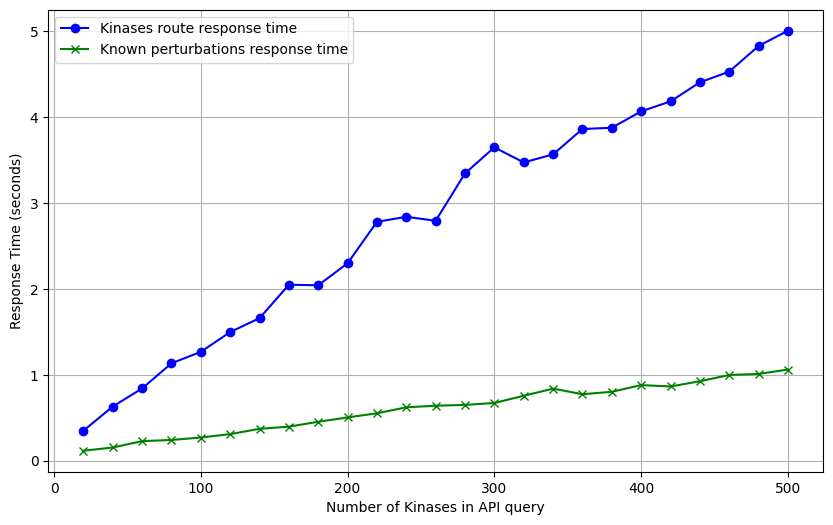

In [58]:
plt.figure(figsize=(10,6))

plt.plot(mean_times_by_batch["Number of kinases"],
         mean_times_by_batch["Kinase Response Time"],
         color="blue", marker='o', label='Kinases route response time')

plt.plot(mean_times_by_batch["Number of kinases"],
         mean_times_by_batch["Known Perturbation Time"],
         color="green", marker='x', label='Known perturbations response time')

plt.xlabel('Number of Kinases in API query')
plt.ylabel('Response Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()


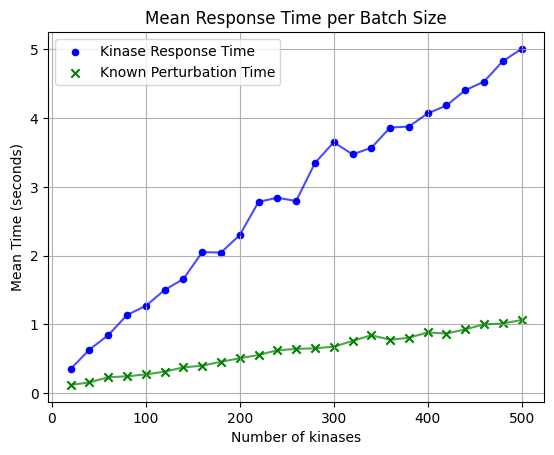

In [56]:
# Scatter plot for Kinase Response Time
mean_times_by_batch.plot(
    x="Number of kinases",
    y="Kinase Response Time",
    kind="scatter",
    color="blue",
    marker='o',
    label="Kinase Response Time"
)
# Reference line that follows the points
plt.plot(
    mean_times_by_batch["Number of kinases"],
    mean_times_by_batch["Kinase Response Time"],
    color="blue",
    linestyle='-',
    alpha=0.7
)

# Scatter plot for Known Perturbation Time (on the same axes)
plt.scatter(
    mean_times_by_batch["Number of kinases"],
    mean_times_by_batch["Known Perturbation Time"],
    color="green",
    marker='x',
    label="Known Perturbation Time"
)
# Reference line for second dataset
plt.plot(
    mean_times_by_batch["Number of kinases"],
    mean_times_by_batch["Known Perturbation Time"],
    color="green",
    linestyle='-',
    alpha=0.7
)

plt.title("Mean Response Time per Batch Size")
plt.xlabel("Number of kinases")
plt.ylabel("Mean Time (seconds)")
plt.grid(True)
plt.legend()
plt.show()


In [47]:
times1 = []
times2 = []
pert_num = []
mtor_perts = ["AC220","Amuvatinib","AT13148","AZ20","AZD1480","AZD3759","AZD5363","AZD5438","AZD6482","AZD6738","AZD8055","Bosutinib","BX912","CAL101","CHIR99021","CX4945","Dabrafenib","Dasatinib","DNAPK","Edelfosine","FRAX486","GDC0941","GDC0994","GF109203X","Go6976","GO6983","GSK2334470","GSK690693","H89","HS173","Ipatasertib","JNJ","JNK","KD025","KN62","KN93","Ku0063794","Linsitinib","LY2090314","LY2584702","LY2835219","MK2206","NU7441","PD153035","PF3758309","PF4708671","PH797804","PIK294","Ribociclib","Ripasudil","Selumetinib","SP600125","TAK715","TBCA","TGX221","Tofacitinib","Torin","Trametinib","U73122","Ulixertinib","Vemurafenib"]
pert_list = []
for i in range(5):
    index = 1
    batch_size = 1
    while index < len(mtor_perts):
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
        }
        api_batch = mtor_perts[:batch_size]
        pert_list = formatList(api_batch)
        url_kin = "https://kinepik.org/api/perturbation/KSEA?kinase_ids=P42345&perturbations="+pert_list+"&cell_line=MCF7"
        ulr_known = "https://kinepik.org/api/perturbation/KSEA?kinase_ids=P42345&perturbations="+pert_list+"&cell_line=MCF7&phosphosite_confidence=1&sid=0.05"
        # requesting the infomation from the url
        start1 = time.perf_counter()
        response1 = requests.get(url_kin, headers=headers)
        end1 = time.perf_counter()
        response_time1 = end1 - start1
        start2 = time.perf_counter()
        response2 = requests.get(ulr_known, headers=headers)
        end2 = time.perf_counter()
        response_time2 = end2 - start2
        times1.append(response_time1)
        times2.append(response_time2)
        pert_num.append(index)
        
        batch_size += 5
        index = batch_size

responses_kin = pd.DataFrame({"Number of perturbations" : pert_num, "No extra filters response Time" : times1, "Filters response Time" : times2})
print(responses_kin)

# After your loop finishes and responses_kin DataFrame is created
mean_times_by_batch = (responses_kin.groupby("Number of perturbations").mean(numeric_only=True).reset_index())

print("Mean response times per batch size:")
print(mean_times_by_batch)


    Number of perturbations  No extra filters response Time  \
0                         1                        1.848052   
1                         6                        8.784519   
2                        11                       15.748842   
3                        16                       23.254097   
4                        21                       30.727359   
5                        26                       37.108228   
6                        31                       43.785530   
7                        36                       51.070544   
8                        41                       58.245205   
9                        46                       60.166992   
10                       51                       60.034640   
11                       56                       60.095706   
12                        1                        5.425155   
13                        6                       24.882161   
14                       11                       34.81

In [72]:
data = pd.read_csv("Mean response times per batch size.tsv", sep = "\t")
print(data.columns)

Index(['Num', 'No-filters', 'Filters'], dtype='object')


<Figure size 1000x600 with 0 Axes>

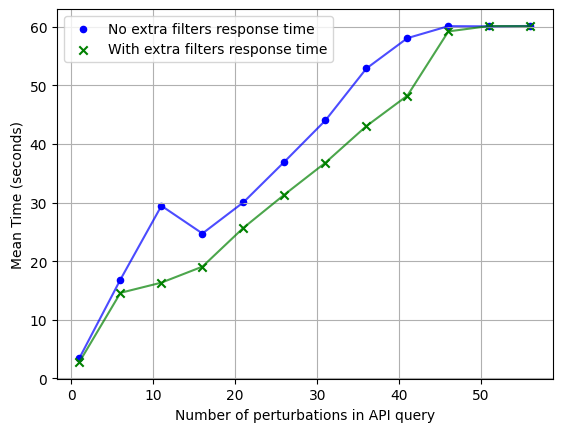

In [75]:
plt.figure(figsize=(10,6))

# Scatter plot for Kinase Response Time
data.plot(
    x="Num",
    y="No-filters",
    kind="scatter",
    color="blue",
    marker='o',
    label="No extra filters response time"
)
# Reference line that follows the points
plt.plot(
    data["Num"],
    data["No-filters"],
    color="blue",
    linestyle='-',
    alpha=0.7
)

# Scatter plot for Filters response Time (on the same axes)
plt.scatter(
    data["Num"],
    data["Filters"],
    color="green",
    marker='x',
    label="With extra filters response time"
)
# Reference line for second dataset
plt.plot(
    data["Num"],
    data["Filters"],
    color="green",
    linestyle='-',
    alpha=0.7
)

#plt.title("Mean Response Time per Batch Size")
plt.xlabel("Number of perturbations in API query")
plt.ylabel("Mean Time (seconds)")
plt.grid(True)
plt.legend()
plt.show()
